In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.colors as colors
import seaborn as sns

In [2]:
traces = pd.read_csv("../traces.dat", delimiter="\t")
# I should come up with a statistical measure
# traces_cut
tc = traces[6000:-6000].reset_index(drop=True).values.flatten()

In [3]:
def remove_signal(trace, sig_window):
    sig = np.argmax(trace)
    return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1))

In [4]:
new_tc = remove_signal(tc, 4)

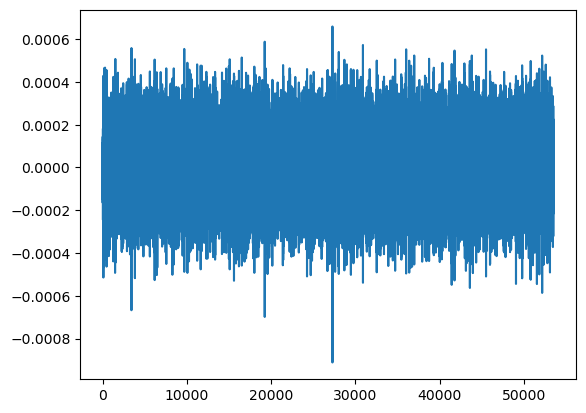

In [5]:
plt.plot(new_tc)
plt.show()
plt.close()

In [6]:
def get_reals(trace, dur):
    to_consider = trace[:-(len(trace)%dur)]
    print(len(to_consider),  len(to_consider)/dur)
    return np.split(to_consider, len(to_consider)/dur)

In [7]:
inp = np.array(get_reals(new_tc, 200))

53400 267.0


In [8]:
cov_try = np.cov(inp.T)

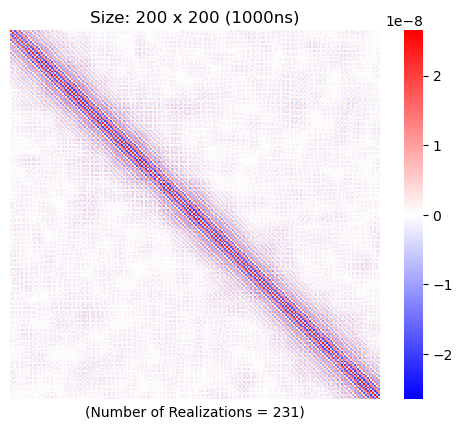

In [9]:
sns.heatmap(cov_try, xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
plt.title("Size: 200 x 200 (1000ns)")
plt.xlabel("(Number of Realizations = 231)")
plt.show()

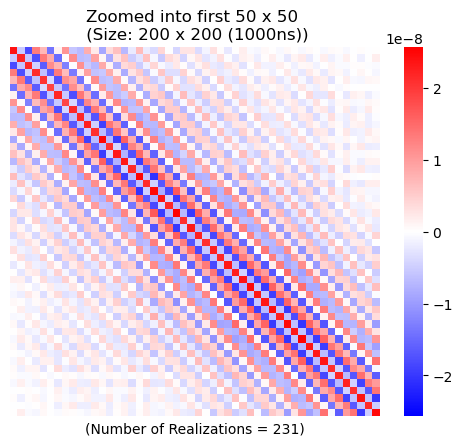

In [10]:
sns.heatmap(cov_try[:50, :50], xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
plt.title("Zoomed into first 50 x 50 \n (Size: 200 x 200 (1000ns))")
plt.xlabel("(Number of Realizations = 231)")
plt.show()

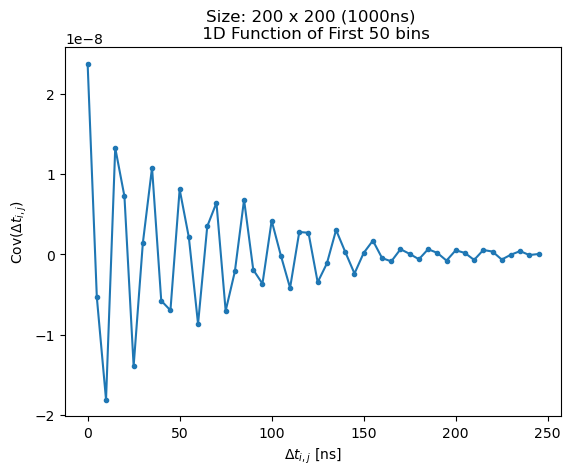

In [11]:
plt.plot(5*np.arange(50), cov_try[0][:50])
plt.scatter(5*np.arange(50),cov_try[0,:50], marker='.')
plt.title("Size: 200 x 200 (1000ns) \n 1D Function of First 50 bins")
plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Cov($\Delta t_{i,j}$)")
plt.show()

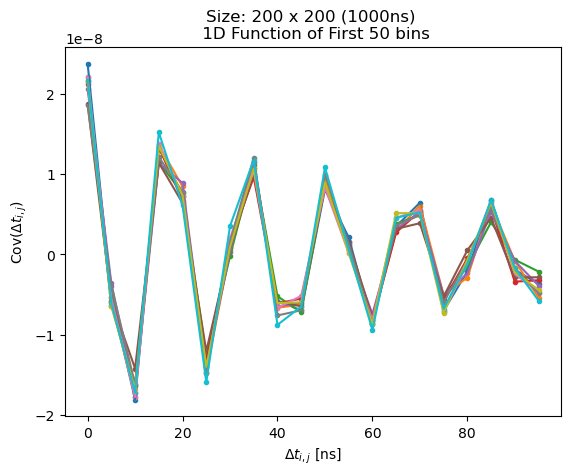

In [12]:
for i in range(10):
    plt.plot(5*np.arange(20), cov_try[i, i:20+i])
    plt.scatter(5*np.arange(20),cov_try[i,i:20+i], marker='.')
plt.title("Size: 200 x 200 (1000ns) \n 1D Function of First 50 bins")
plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Cov($\Delta t_{i,j}$)")
plt.show()

In [14]:
np.linspace(0, 200, 10).astype(int)

array([  0,  22,  44,  66,  88, 111, 133, 155, 177, 200])

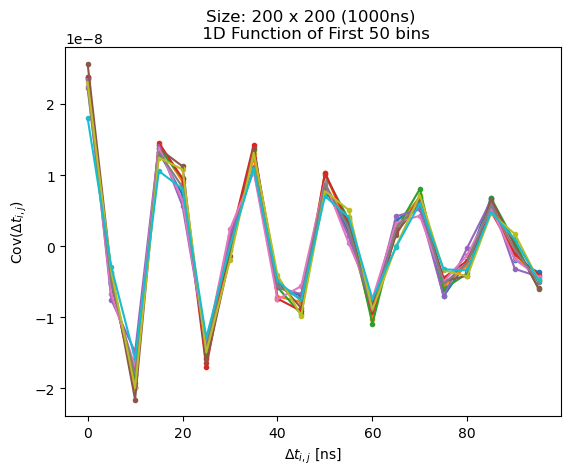

In [ ]:
dur = 200
for i in np.linspace(0, dur, 10).astype(int):
    if dur < 20:
        
    plt.plot(5*np.arange(20), cov_try[i, i:20+i])
    plt.scatter(5*np.arange(20),cov_try[i,i:20+i], marker='.')
plt.title("Size: 200 x 200 (1000ns) \n 1D Function of First 50 bins")
plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
plt.ylabel(r"Cov($\Delta t_{i,j}$)")
plt.show()

In [7]:
def make_cov(trace, duration, sig_window):
    new_trace = remove_signal(trace, sig_window)
    reals = get_reals(new_trace, duration)
    N = len(reals)

    if N==0:
        return np.zeros((duration, duration)), N
    
    mus = np.average(reals, axis=0)
    diffs = reals-mus

    cov = np.empty((duration, duration))
    for i in range(duration):
        for j in range(duration-i):
            cov[i, i+j] = np.sum(diffs[:,i]*diffs[:,j])/N
            cov[i+j,j] = cov[i,i+j]

    return cov, N


53400 267.0
53500 107.0


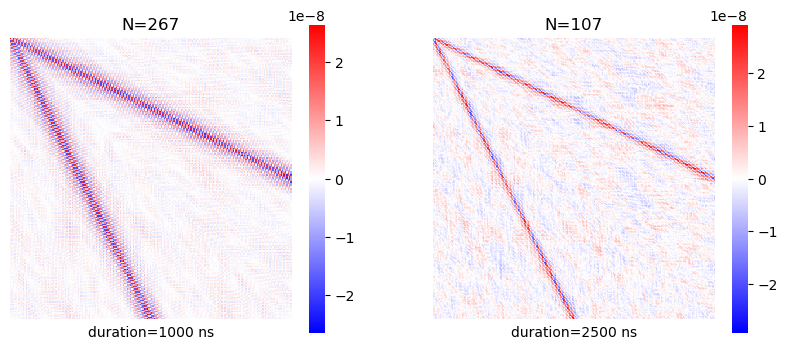

In [8]:
# Focus on top 2
tc = traces[6000:-6000].reset_index(drop=True).values.flatten()
durs = np.array([200, 500])

dursN = len(durs)

fig, axes = plt.subplots(nrows=1, ncols=dursN, figsize=(5*dursN, 4))

for j in range(dursN):
    cov, N = make_cov(tc, durs[j], 4)
    sns.heatmap(cov, xticklabels=False, yticklabels=False, ax=axes[j], square=True, cmap="bwr", norm=colors.CenteredNorm())
    axes[j].set_title(f"N={N}")
    axes[j].set_xlabel(f"duration={durs[j]*5} ns")

plt.show()
plt.close()